# Boostrap

This notebook implements bootstrap to assess the accuracy of OLS estimates. Suppose the model is the following:

$$
r_{i}^{t+1} = X_{i}^t \beta + \epsilon_i
$$

where $r_{i}^{t+1}$ is next month return of stock $i$ and X_{i}^t is a matrix of stock characteristics at time $t$, including:
- Investment growth
- Profitability
- Log market equity
- Log book equity
- Accruals

Importantly, we fix the date at 2022-06-30. Thus, we perform a cross-sectional regression

## 0. Required packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

## 1. Load and prepare data

In [3]:
# -----------------------------
# Load + create next-month return
# -----------------------------
data = pd.read_stata("Stocks_Monthly.dta")
data = data.sort_values(["permno", "date"]).copy()
data["date"] = pd.to_datetime(data["date"])

# next month return (t+1)
data["ret_t+1"] = data.groupby("permno")["ret"].shift(-1)

# One pure cross-section (example month)
cs_date = pd.Timestamp("2022-06-30")
cols = ["permno", "date", "Gat", "profit", "LNme", "LNbe", "accruals", "ret_t+1"]
data = data.loc[data["date"].eq(cs_date), cols].dropna().copy()

features = ["Gat", "profit", "LNme", "LNbe", "accruals"]
X = data[features].to_numpy()
y = data["ret_t+1"].to_numpy()
n = len(y)

## 2. OLS estimates

In [4]:
# -----------------------------
# 1) Original (full-sample) fit — sklearn + statsmodels for SEs
# -----------------------------
lr = LinearRegression()
lr.fit(X, y)
orig_coefs = lr.coef_
orig_intercept = lr.intercept_

# OLS standard errors via statsmodels
X_sm = sm.add_constant(X)
ols_res = sm.OLS(y, X_sm).fit()
ols_se = ols_res.bse[1:]          # feature SEs (skip intercept)
ols_se_intercept = ols_res.bse[0]  # intercept SE

# 3. Boostrap

Boostrap is performed by randomly sampling with replacement observations from our original sample. For each boostrap sample we estimate the model and store the coefficients

In [6]:
# -----------------------------
# 2) Bootstrap
# -----------------------------
np.random.seed(42)
B = 10_000  # number of bootstrap replications

boot_coefs = np.zeros((B, len(features)))
boot_intercepts = np.zeros(B)

for b in range(B):
    # Resample n observations WITH replacement
    idx = np.random.choice(n, size=n, replace=True)
    X_b = X[idx]
    y_b = y[idx]

    model_b = LinearRegression().fit(X_b, y_b)
    boot_coefs[b, :] = model_b.coef_
    boot_intercepts[b] = model_b.intercept_

## 4. Boostrap statistics


Bootstrap Inference (B=10,000 replications)
   Feature |       Coef |     OLS SE |    Boot SE |   t-stat | 95% CI low | 95% CI high | p<0.05
------------------------------------------------------------------------------------------
       Gat |   0.037308 |   0.008100 |   0.011782 |     3.17 |   0.014320 |    0.060676 |      *
    profit |   0.000412 |   0.000308 |   0.001858 |     0.22 |  -0.000064 |    0.005784 |       
      LNme |   0.015408 |   0.003079 |   0.003230 |     4.77 |   0.008860 |    0.021614 |      *
      LNbe |  -0.008510 |   0.003568 |   0.003711 |    -2.29 |  -0.016072 |   -0.001446 |      *
  accruals |   0.002965 |   0.005691 |   0.008295 |     0.36 |  -0.010373 |    0.022433 |       
 intercept |   0.025794 |   0.010607 |   0.013181 |     1.96 |   0.003389 |    0.054599 |      *

Bootstrap Bias Estimates:
   Feature |   Original |  Boot Mean |       Bias
--------------------------------------------------
       Gat |   0.037308 |   0.036839 |  -0.000470
    pro

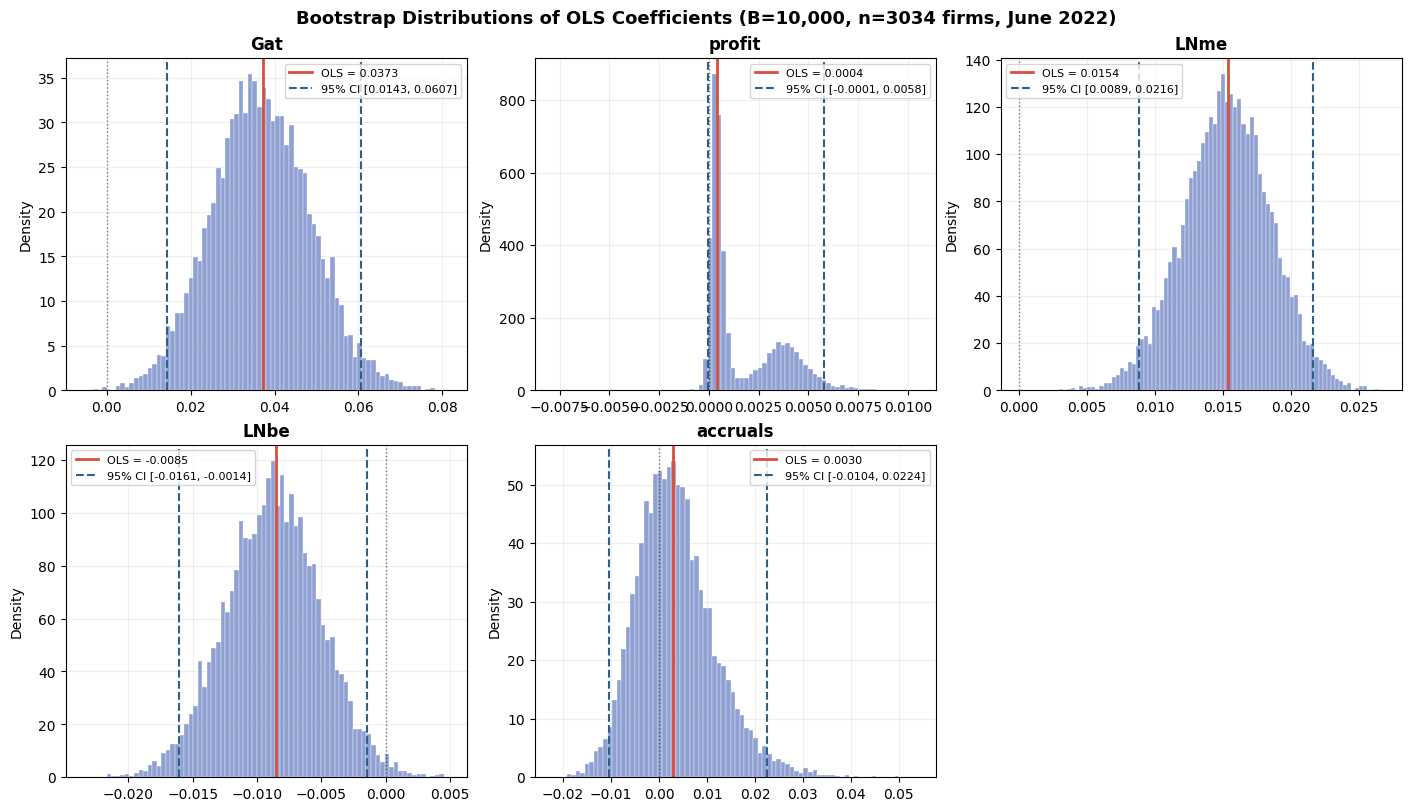

In [5]:
# -----------------------------
# 3) Bootstrap standard errors & confidence intervals
# -----------------------------
alpha = 0.05

print(f"\n{'='*90}")
print(f"Bootstrap Inference (B={B:,} replications)")
print(f"{'='*90}")
print(f"{'Feature':>10s} | {'Coef':>10s} | {'OLS SE':>10s} | {'Boot SE':>10s} | {'t-stat':>8s} | "
      f"{'95% CI low':>10s} | {'95% CI high':>11s} | {'p<0.05':>6s}")
print(f"{'-'*90}")

results = []
for j, name in enumerate(features):
    coef = orig_coefs[j]
    boot_se = boot_coefs[:, j].std(ddof=1)
    orig_se = ols_se[j]
    t_stat = coef / boot_se if boot_se > 0 else np.nan
    # Percentile method CI
    ci_lo = np.percentile(boot_coefs[:, j], 100 * alpha / 2)
    ci_hi = np.percentile(boot_coefs[:, j], 100 * (1 - alpha / 2))
    sig = "*" if (ci_lo > 0 or ci_hi < 0) else ""

    print(f"{name:>10s} | {coef: 10.6f} | {orig_se: 10.6f} | {boot_se: 10.6f} | {t_stat: 8.2f} | "
          f"{ci_lo: 10.6f} | {ci_hi: 11.6f} | {sig:>6s}")

    results.append({
        "name": name, "coef": coef, "ols_se": orig_se, "boot_se": boot_se,
        "ci_lo": ci_lo, "ci_hi": ci_hi, "t_stat": t_stat
    })

# Intercept
boot_se_int = boot_intercepts.std(ddof=1)
ci_lo_int = np.percentile(boot_intercepts, 100 * alpha / 2)
ci_hi_int = np.percentile(boot_intercepts, 100 * (1 - alpha / 2))
t_int = orig_intercept / boot_se_int if boot_se_int > 0 else np.nan
sig_int = "*" if (ci_lo_int > 0 or ci_hi_int < 0) else ""
print(f"{'intercept':>10s} | {orig_intercept: 10.6f} | {ols_se_intercept: 10.6f} | {boot_se_int: 10.6f} | {t_int: 8.2f} | "
      f"{ci_lo_int: 10.6f} | {ci_hi_int: 11.6f} | {sig_int:>6s}")

# -----------------------------
# 4) Bootstrap bias estimate
# -----------------------------
print(f"\nBootstrap Bias Estimates:")
print(f"{'Feature':>10s} | {'Original':>10s} | {'Boot Mean':>10s} | {'Bias':>10s}")
print(f"{'-'*50}")
for j, name in enumerate(features):
    boot_mean = boot_coefs[:, j].mean()
    bias = boot_mean - orig_coefs[j]
    print(f"{name:>10s} | {orig_coefs[j]: 10.6f} | {boot_mean: 10.6f} | {bias: 10.6f}")

# -----------------------------
# 5) Visualisation: bootstrap distributions
# -----------------------------
n_features = len(features)
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
axes = axes.flatten()

for j, name in enumerate(features):
    ax = axes[j]
    r = results[j]

    ax.hist(boot_coefs[:, j], bins=80, color="#7B8FCC", edgecolor="white",
            linewidth=0.3, alpha=0.85, density=True)

    # Original estimate
    ax.axvline(r["coef"], color="#D94E3F", linewidth=2, label=f'OLS = {r["coef"]:.4f}')
    # CI bounds
    ax.axvline(r["ci_lo"], color="#2C5F8A", linewidth=1.5, linestyle="--",
               label=f'95% CI [{r["ci_lo"]:.4f}, {r["ci_hi"]:.4f}]')
    ax.axvline(r["ci_hi"], color="#2C5F8A", linewidth=1.5, linestyle="--")
    # Zero line
    ax.axvline(0, color="black", linewidth=1, linestyle=":", alpha=0.5)

    ax.set_title(name, fontweight="bold", fontsize=12)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8, frameon=True)
    ax.grid(True, alpha=0.2)

# Hide unused subplot
axes[-1].set_visible(False)

fig.suptitle(f"Bootstrap Distributions of OLS Coefficients (B={B:,}, n={n} firms, June 2022)",
             fontsize=13, fontweight="bold")

plt.savefig("Ch4_Bootstrap.png", dpi=300, bbox_inches="tight")
